# Farmer–Intermediary Data EDA

Hi there! This notebook analyzes the empirical farmer/intermediary pickup data used to calibrate the synthetic instance generator.

The main statistics analyzed are:

1. farmer-network size by intermediary,
2. farmer quantity distributions,
3. pickup periodicity and schedule perturbations,
4. daily number of pickups,
5. pickup-route localization, and
6. farmer–intermediary distance distributions.


In [59]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import osmnx as ox

sns.set_theme(context="paper", style="darkgrid")

INDO_CRS = "EPSG:23867"
DATA_DIR = Path("../data")

FARMERS_PATH = DATA_DIR / "farmers.csv"
FARMERS_2_PATH = DATA_DIR / "farmers_2.csv"
INTS_PATH = DATA_DIR / "ints.csv"
MILLS_PATH = DATA_DIR / "mills.csv"

GRAPH_PATH_CANDIDATES = [
    DATA_DIR / "graph_0-14960_00_new.pickle",
    DATA_DIR / "graph_0-14960_00.pickle",
    Path("../FactoredPlatformSolver/data/graph_0-14960_00_new.pickle"),
    Path("../FactoredPlatformSolver/data/graph_0-14960_00.pickle"),
]

PLOTS_DIR = Path("../results/eda")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


## Load data


In [ ]:
def first_existing_path(paths):
    for path in paths:
        if path.exists():
            return path
    paths_str = "\n".join(map(str, paths))
    raise FileNotFoundError(f"None of the candidate paths exist:\n{paths_str}")


def load_graph(path_candidates=GRAPH_PATH_CANDIDATES, target_crs=INDO_CRS):
    graph_path = first_existing_path(path_candidates)
    with open(graph_path, "rb") as f:
        graph = pickle.load(f)

    graph_crs = graph.graph.get("crs")
    if graph_crs is None or str(graph_crs) != target_crs:
        graph = ox.project_graph(graph, to_crs=target_crs)

    return graph, graph_path


farmers_df = pd.read_csv(FARMERS_PATH)
ints_df = pd.read_csv(INTS_PATH)
mills_df = pd.read_csv(MILLS_PATH) if MILLS_PATH.exists() else None
G_proj, graph_path = load_graph()

print(f"farmers_df: {farmers_df.shape}")
print(f"ints_df:    {ints_df.shape}")

if mills_df is not None:
    print(f"mills_df:   {mills_df.shape}")
print(f"graph:      {len(G_proj.nodes):,} nodes, {len(G_proj.edges):,} edges")
print(f"graph_path: {graph_path}")

farmers_df.head()


In [61]:
# Build a stable anonymization map
int_ids = sorted(ints_df["int_id"].dropna().unique())

int_name_map = {
    int_id: f"Intermediary {i+1}"
    for i, int_id in enumerate(int_ids)
}

# Apply to dataframe
ints_df["int_id_anon"] = ints_df["int_id"].map(int_name_map)
farmers_df["int_id_anon"] = farmers_df["int_id"].map(int_name_map)

In [62]:
def save_current_fig(filename, dpi=200):
    out_path = PLOTS_DIR / filename
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved {out_path}")


def facet_hist_by_intermediary(
    data,
    x,
    *,
    bins=None,
    discrete=False,
    title=None,
    xlabel=None,
    ylabel="Percent",
    ylim=None,
    xticks=None,
    xlim=None,
    col_wrap=4,
    height=2.4,
    aspect=1.25,
):
    plot_df = data.copy()
    plot_df["int_id_anon"] = plot_df["int_id_anon"].astype(str)

    g = sns.displot(
        data=plot_df.sort_values("int_id_anon"),
        x=x,
        col="int_id_anon",
        col_wrap=col_wrap,
        bins=bins,
        discrete=discrete,
        stat="percent",
        common_norm=False,
        facet_kws={
            "sharex": True,
            "sharey": True,
            "margin_titles": False,
        },
        height=height,
        aspect=aspect,
        edgecolor="white",
        linewidth=0.5,
    )

    g.set_titles("{col_name}", size=10)
    g.set_axis_labels(xlabel or x, ylabel)

    for ax in g.axes.flatten():
        ax.grid(True, axis="y", alpha=0.25)
        ax.grid(False, axis="x")
        ax.tick_params(axis="x", labelsize=8, labelbottom=True)
        ax.tick_params(axis="y", labelsize=8)

        if xticks is not None:
            ax.set_xticks(xticks)
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)

    if title is not None:
        g.figure.suptitle(title, fontsize=15, y=1.03)

    g.figure.tight_layout()
    return g


## 1. How many farmers are in each intermediary's network?

This uses unique farmer locations within each intermediary network to avoid counting repeat pickups of the same farmer-location pair multiple times.


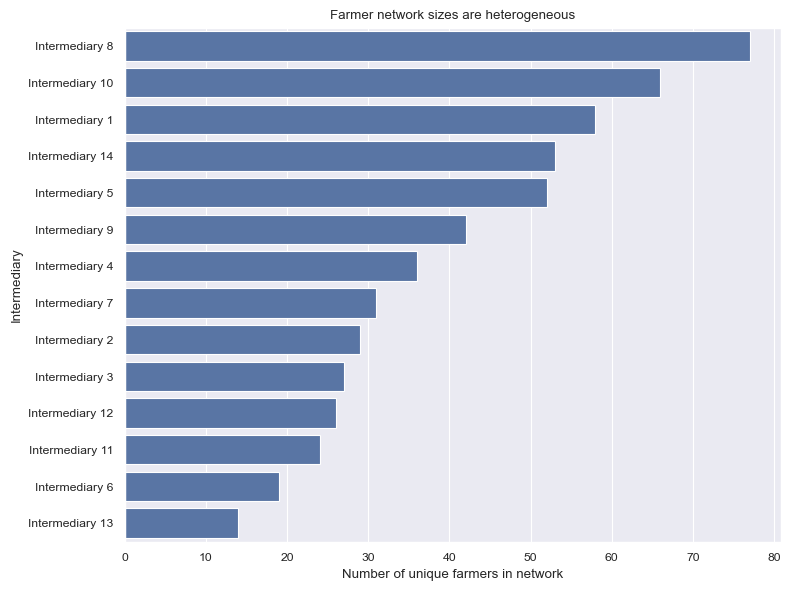

In [22]:
network_sizes = (
    farmers_df
    .drop_duplicates(["int_id", "farmer_x", "farmer_y"])
    .groupby("int_id_anon")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))
sns.barplot(x=network_sizes.values, y=network_sizes.index)
plt.ylabel("Intermediary")
plt.xlabel("Number of unique farmers in network")
plt.title("Farmer network sizes are heterogeneous")
plt.tight_layout()
plt.show()


## 2. How much do farmers in each intermediary's network produce?


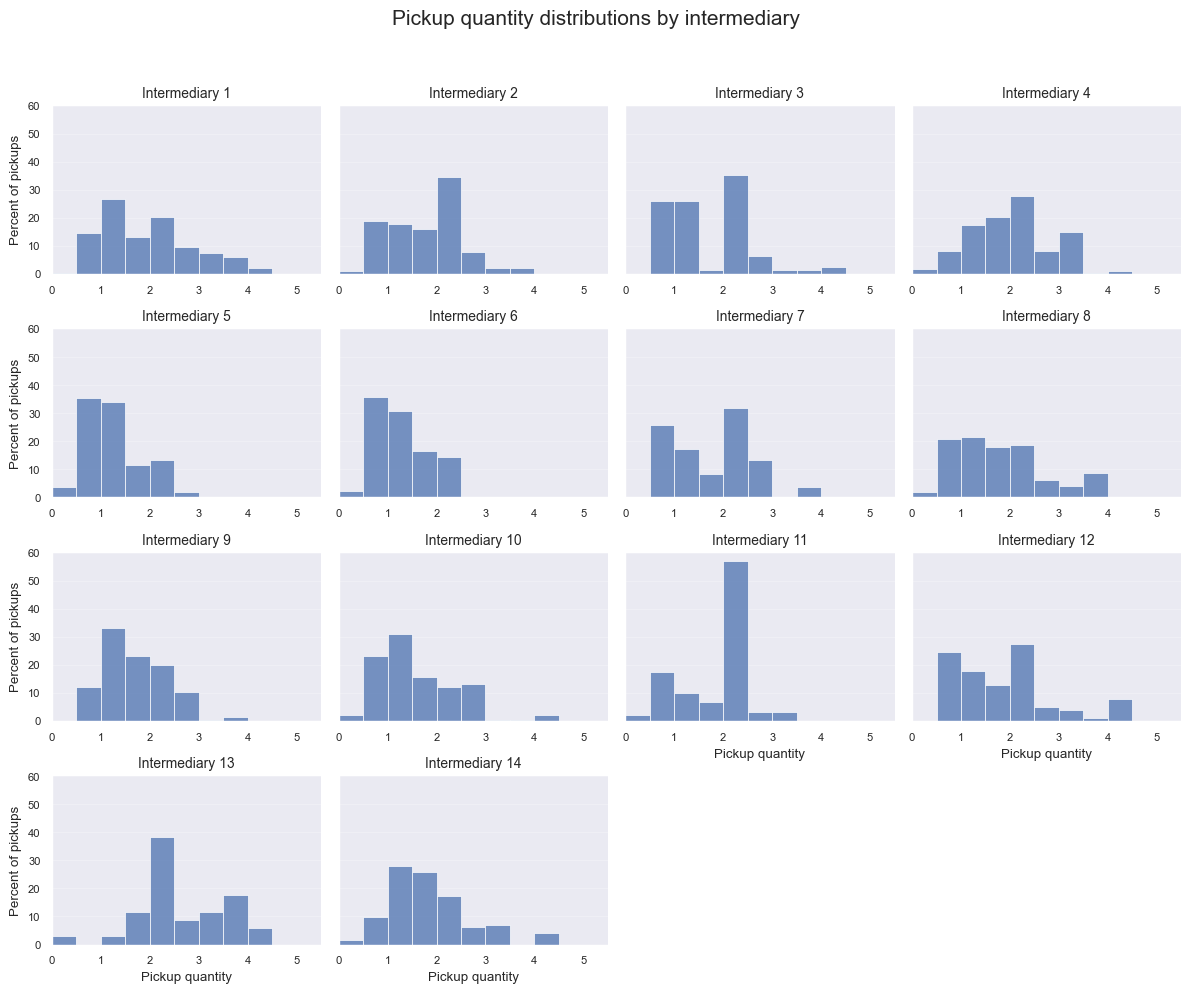

In [23]:
quantity_df = farmers_df.copy()
quantity_bins = np.arange(0, quantity_df["quantity"].max() + 0.5, 0.5)
quantity_xticks = np.arange(0, quantity_df["quantity"].max() + 1, 1.0)

g = facet_hist_by_intermediary(
    quantity_df,
    "quantity",
    bins=quantity_bins,
    title="Pickup quantity distributions by intermediary",
    xlabel="Pickup quantity",
    ylabel="Percent of pickups",
    col_wrap=4,
    height=2.4,
    aspect=1.25,
    xlim=(0, quantity_xticks.max() + 0.5),
    xticks=quantity_xticks,
)
plt.show()


## 3. Are pickups roughly every two weeks?


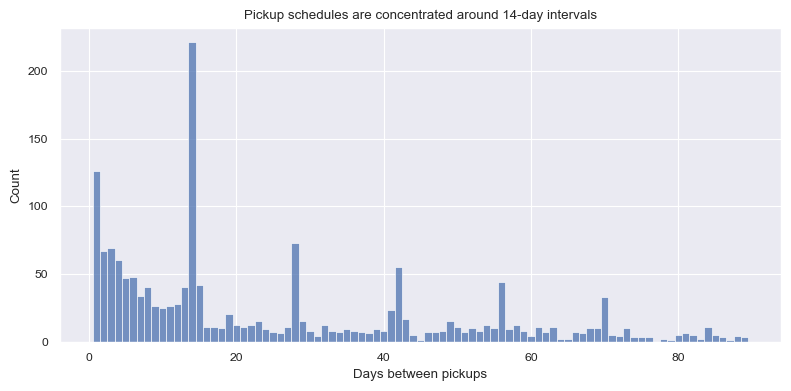

count    1656.000000
mean       25.112319
std        22.979317
min         1.000000
25%         6.000000
50%        14.000000
75%        42.000000
max        89.000000
Name: date, dtype: float64

In [24]:
pickups_df = farmers_df.copy()
pickups_df["date"] = pd.to_datetime(pickups_df["date"])
pickups_df = pickups_df.sort_values(["int_id_anon", "farmer_x", "farmer_y", "date"])

pickup_gaps = (
    pickups_df
    .groupby(["int_id_anon", "farmer_x", "farmer_y"])["date"]
    .diff()
    .dt.days
)

pickup_gaps = pickup_gaps[(pickup_gaps > 0) & (pickup_gaps < 90)]

plt.figure(figsize=(8, 4))
sns.histplot(pickup_gaps.dropna(), discrete=True)
plt.xlabel("Days between pickups")
plt.ylabel("Count")
plt.title("Pickup schedules are concentrated around 14-day intervals")
plt.tight_layout()
plt.show()

pickup_gaps.describe()


In [25]:
def compute_perturbations(group, period=14):
    """Estimate deviations from a regular period-day pickup schedule."""
    group = group.sort_values("date").copy()
    dates = group["date"].values.astype("datetime64[D]")
    t = (dates - dates[0]).astype(int)

    cycle_index = np.round(t / period).astype(int)
    phase = int(np.round(np.median(t - period * cycle_index)))
    group["epsilon"] = t - (phase + period * cycle_index)

    return group


schedule_df = (
    pickups_df
    .groupby(["int_id_anon", "farmer_x", "farmer_y"], group_keys=False)
    .apply(compute_perturbations)
)

abs_eps = schedule_df["epsilon"].abs()
print(f"80th percentile absolute perturbation: {int(abs_eps.quantile(0.80))} days")
print(f"90th percentile absolute perturbation: {int(abs_eps.quantile(0.90))} days")
print(f"95th percentile absolute perturbation: {int(abs_eps.quantile(0.95))} days")


80th percentile absolute perturbation: 3 days
90th percentile absolute perturbation: 5 days
95th percentile absolute perturbation: 6 days


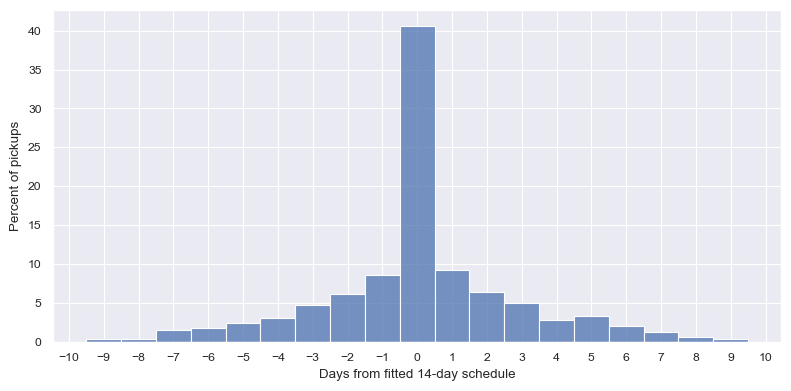

In [65]:
eps = schedule_df["epsilon"]
eps = eps[(eps > -10) & (eps < 10)]

plt.figure(figsize=(8, 4))
sns.histplot(eps, bins=20, discrete=True, stat="percent")
plt.xlabel("Days from fitted 14-day schedule")
plt.ylabel("Percent of pickups")
plt.xticks(np.arange(-10, 11, 1))
# plt.title("Most pickups are close to a 14-day schedule")
plt.tight_layout()
plt.savefig("../figures/eda_14_day_cycle.png", dpi=300, bbox_inches="tight")
plt.show()


Notes:
- Majority of pickups are exactly on 14 day cycles (40%)
- 80% of pickups are within 3 days of the cycle.

## 4. How many farmers do intermediaries pick up from daily?


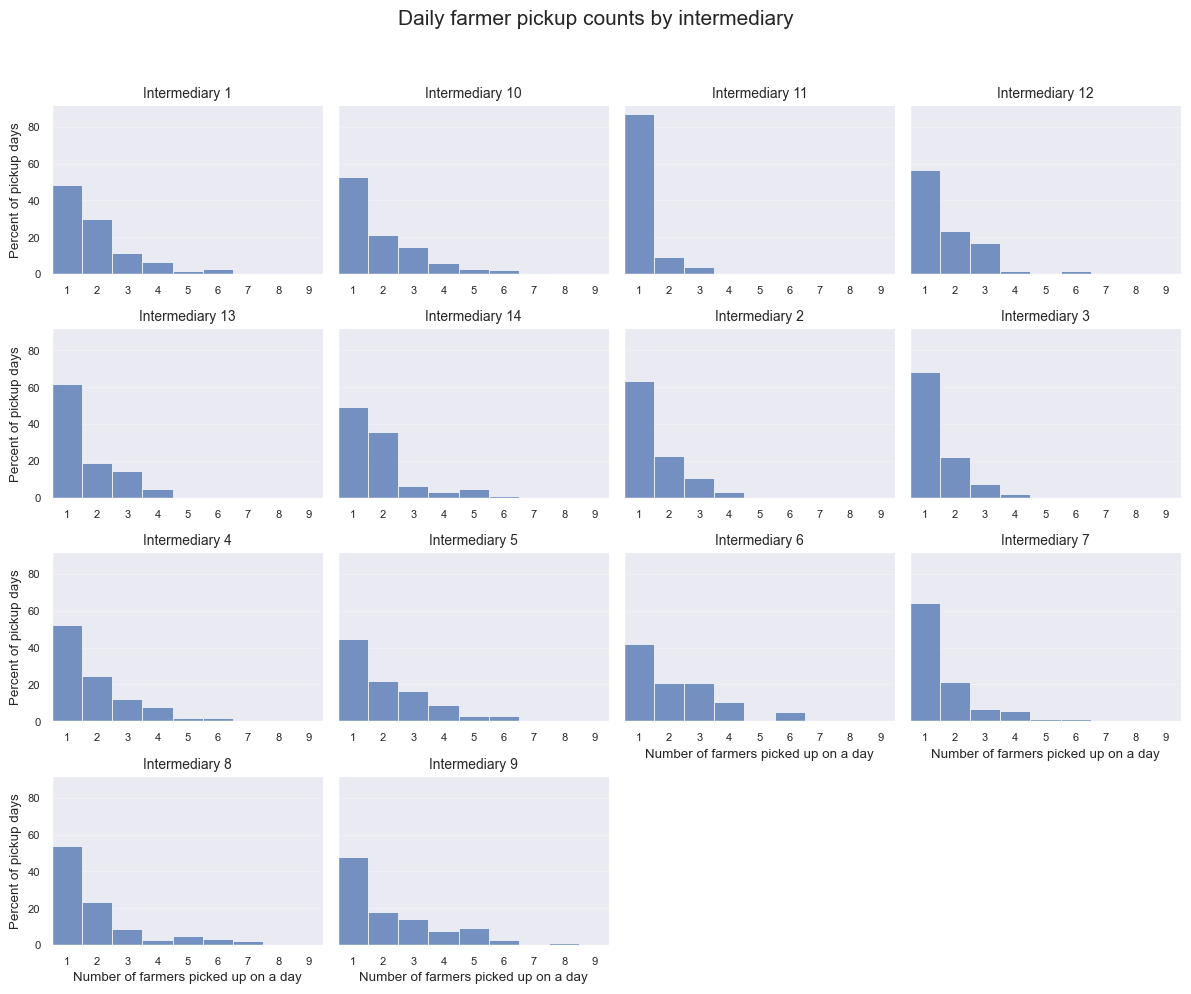

In [30]:
daily_pickup_counts = (
    farmers_df
    .groupby(["int_id_anon", "date"])
    .size()
    .reset_index(name="count")
)

count_bins = np.arange(0.5, daily_pickup_counts["count"].max() + 1.5, 1)
count_xticks = np.arange(1, daily_pickup_counts["count"].max() + 1)

g = facet_hist_by_intermediary(
    daily_pickup_counts,
    "count",
    bins=count_bins,
    discrete=True,
    title="Daily farmer pickup counts by intermediary",
    xlabel="Number of farmers picked up on a day",
    ylabel="Percent of pickup days",
    col_wrap=4,
    height=2.4,
    aspect=1.25,
    xlim=(0.5, count_xticks.max() + 0.5),
    xticks=count_xticks,
)
plt.show()


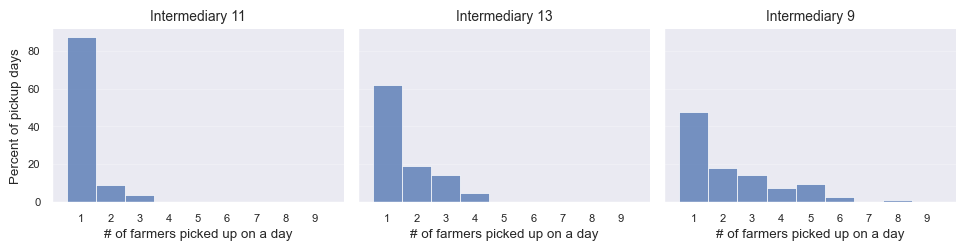

In [64]:
daily_pickup_counts_plot_df = daily_pickup_counts.copy()
daily_pickup_counts_plot_df["int_id_original"] = daily_pickup_counts_plot_df["int_id_anon"]

selected_ints = ["Intermediary 11", "Intermediary 13", "Intermediary 9"]

daily_pickup_counts_plot_df = daily_pickup_counts_plot_df[
    daily_pickup_counts_plot_df["int_id_anon"].isin(selected_ints)
].copy()

count_bins = np.arange(0.5, daily_pickup_counts["count"].max() + 1.5, 1)
count_xticks = np.arange(1, daily_pickup_counts["count"].max() + 1)

g = facet_hist_by_intermediary(
    daily_pickup_counts_plot_df,
    "count",
    bins=count_bins,
    # title="Farmer–intermediary distance distributions",
    xlabel="# of farmers picked up on a day",
    ylabel="Percent of pickup days",
    col_wrap=3,
    height=2.6,
    aspect=1.25,
    xticks=count_xticks,
    xlim=(0, 10),
)

plt.savefig("../figures/eda_farmer_n_pickups.png", dpi=300, bbox_inches="tight")

plt.show()

## 5. How far are pickups from each other on the same date?

This approximates the length of each daily route using a road-network TSP heuristic over unique farmer nodes for each `(int_id, date)` group. This can be computationally expensive, so the result is cached in `results/eda/daily_road_travel_km.csv`.


In [49]:
CACHE_PATH = PLOTS_DIR / "daily_road_travel_km.csv"


def add_nearest_road_nodes(df, graph):
    out = df.copy()
    out["node_id"] = ox.nearest_nodes(graph, out["farmer_x"], out["farmer_y"])
    return out


def solve_road_tsp_distance(group, graph):
    """Approximate shortest open route visiting all unique farmer nodes in a group."""
    nodes = [node for node in group["node_id"].dropna().unique().tolist() if node in graph]

    if len(nodes) < 2:
        return 0.0

    dist_matrix = {}
    for u in nodes:
        lengths = nx.single_source_dijkstra_path_length(graph, u, weight="length")
        dist_matrix[u] = {v: lengths[v] for v in nodes if v in lengths}

    valid_nodes = list(dist_matrix.keys())
    if len(valid_nodes) < 2:
        return 0.0

    tsp_graph = nx.Graph()
    for i, u in enumerate(valid_nodes):
        for v in valid_nodes[i + 1:]:
            if v in dist_matrix[u]:
                tsp_graph.add_edge(u, v, weight=dist_matrix[u][v])

    if tsp_graph.number_of_edges() == 0:
        return np.nan

    try:
        tsp_path = nx.approximation.traveling_salesman_problem(
            tsp_graph,
            cycle=False,
            weight="weight",
        )
        return sum(dist_matrix[tsp_path[i]][tsp_path[i + 1]] for i in range(len(tsp_path) - 1))
    except Exception:
        return np.nan


if CACHE_PATH.exists():
    daily_road_travel = pd.read_csv(CACHE_PATH)
else:
    route_df = add_nearest_road_nodes(farmers_df, G_proj)
    daily_road_travel = (
        route_df
        .groupby(["int_id", "date"])
        .apply(lambda g: solve_road_tsp_distance(g, G_proj), include_groups=False)
        .reset_index(name="distance_m")
    )
    daily_road_travel["distance_km"] = daily_road_travel["distance_m"] / 1000
    daily_road_travel.to_csv(CACHE_PATH, index=False)
    print(f"Cached {CACHE_PATH}")

daily_km = daily_road_travel.loc[daily_road_travel["distance_km"] > 0, "distance_km"]
daily_km.describe()


count    561.000000
mean      13.572670
std       16.746957
min        0.352191
25%        3.756416
50%        7.943098
75%       14.543065
max      102.200068
Name: distance_km, dtype: float64

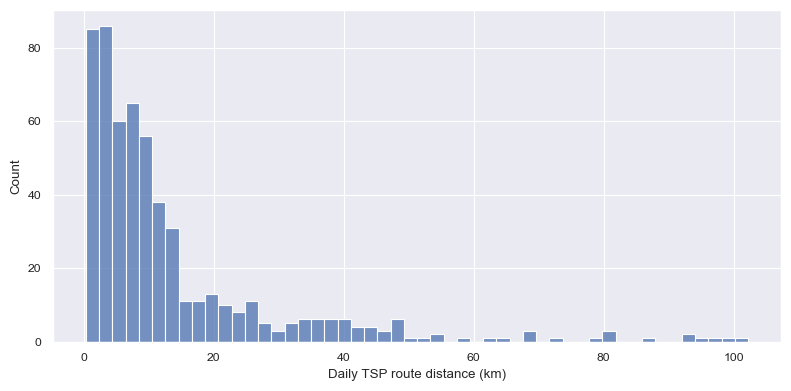

<Figure size 640x480 with 0 Axes>

In [52]:
plt.figure(figsize=(8, 4))
sns.histplot(daily_km, bins=50)
plt.xlabel("Daily TSP route distance (km)")
plt.ylabel("Count")
# plt.title("Most daily routes are localized")
plt.tight_layout()
plt.show()

plt.savefig("../figures/eda_tsp_distances.png", dpi=200, bbox_inches="tight")


Notes:
- Most daily routes are not that long: <30km road distance tours.
- There are a handful of instances where you have *very* long routes, but these are exceedingly rare.

## 6. How far are farmers from their intermediaries?


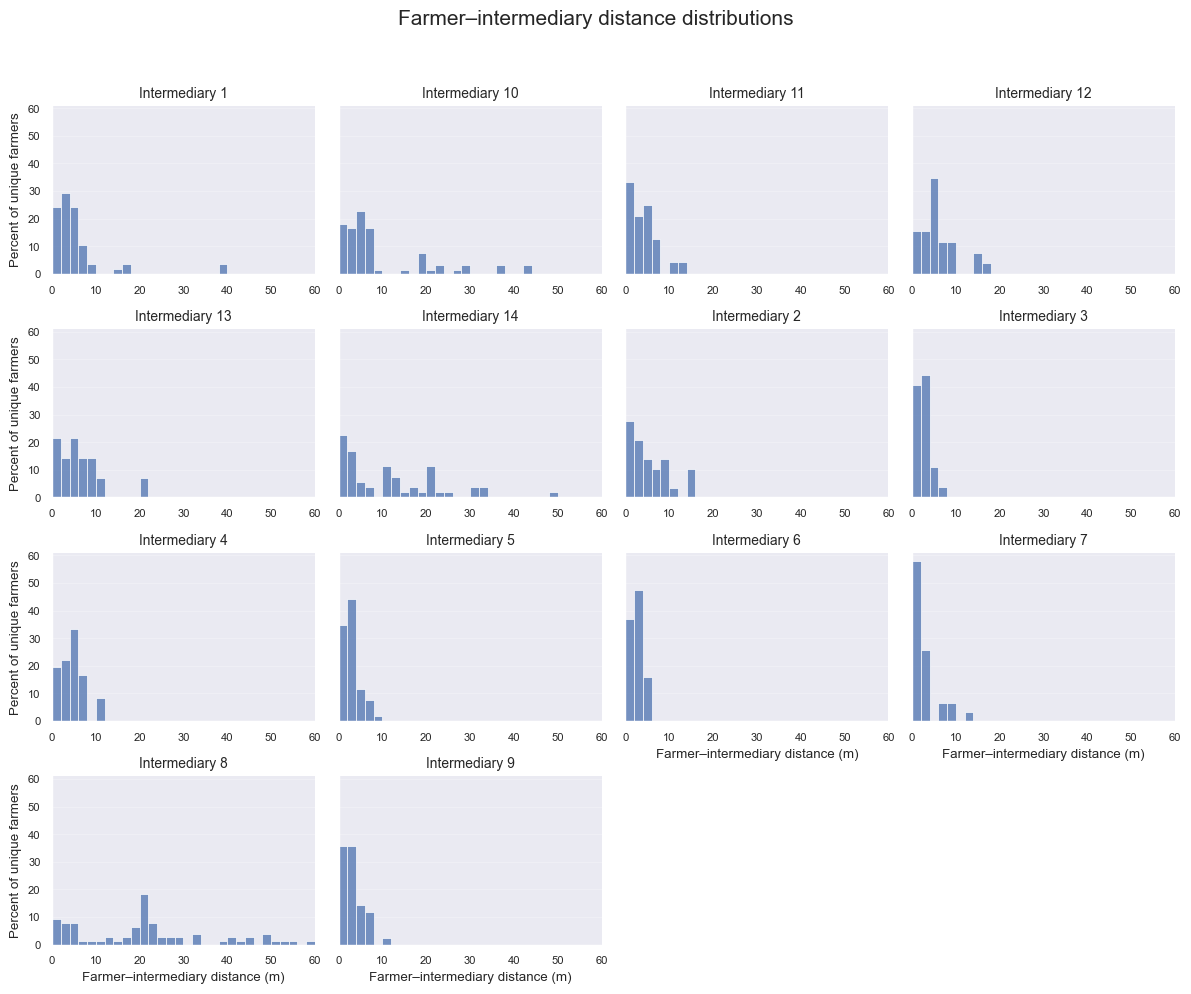

In [33]:
distance_df = farmers_df.drop_duplicates(["int_id", "farmer_x", "farmer_y"]).copy()
distance_df["distance"] = distance_df["distance"] / 1000

distance_xticks = np.arange(0, 60 + 1, 10)
distance_bins = np.arange(0, 60 + 5, 2)

g = facet_hist_by_intermediary(
    distance_df,
    "distance",
    bins=distance_bins,
    title="Farmer–intermediary distance distributions",
    xlabel="Farmer–intermediary distance (m)",
    ylabel="Percent of unique farmers",
    col_wrap=4,
    height=2.4,
    aspect=1.25,
    xticks=distance_xticks,
    xlim=(0, 60),
)


plt.show()


In [34]:
distance_plot_df = distance_df.copy()
distance_plot_df["int_id_original"] = distance_plot_df["int_id"]
distance_plot_df["int_id"] = distance_plot_df["int_id"].map(int_name_map)

selected_ints = ["Intermediary 7", "Intermediary 8", "Intermediary 10"]

distance_plot_df = distance_plot_df[
    distance_plot_df["int_id"].isin(selected_ints)
].copy()

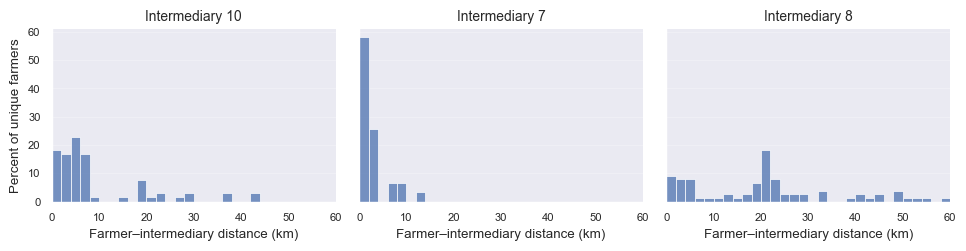

In [63]:
distance_xticks = np.arange(0, 60 + 1, 10)
distance_bins = np.arange(0, 60 + 5, 2)

g = facet_hist_by_intermediary(
    distance_plot_df,
    "distance",
    bins=distance_bins,
    # title="Farmer–intermediary distance distributions",
    xlabel="Farmer–intermediary distance (km)",
    ylabel="Percent of unique farmers",
    col_wrap=3,
    height=2.6,
    aspect=1.25,
    xticks=distance_xticks,
    xlim=(0, 60),
)

plt.savefig("../figures/eda_farmer_int_distance_selected.png", dpi=300, bbox_inches="tight")

plt.show()

## Notes for synthetic instance generation

The EDA above motivates the generator choices used in `InstanceGenerator`:

- intermediary-specific network sizes are heterogeneous;
- quantities are sampled from empirical intermediary-specific pickup quantities;
- pickups are approximately biweekly but include perturbations;
- daily pickup counts vary by intermediary;
- farmer locations are spatially clustered and road-localized;
- farmer–intermediary distances are intermediary-specific.
